# Task 3 — Squad Market Value: UEFA vs. Non-UEFA Teams

## Analytic question formulation

**Do squads from UEFA (European) national federations carry a significantly
higher market value than squads from non-UEFA confederations at the 2026
FIFA World Cup?**

UEFA sides stock their squads almost entirely from Europe's "big five"
leagues, which command the highest transfer valuations in world football.
This task tests whether that financial gap is statistically detectable
across the 48 competing nations, using each team's Transfermarkt-valued
26-player World Cup squad.

**Skills demonstrated:** data wrangling → sampling → descriptive statistics
→ confidence interval → two-sample *t*-test.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_prep import load_teams
from stats_utils import describe, ci_mean, two_sample_ttest, levene_test

np.random.seed(42)
pd.set_option("display.max_columns", None)

teams = load_teams()
teams.head()

,team,confederation,host,fifa_rank_pretournament,prev_wc_titles,prev_wc_appearances,squad_avg_age,squad_market_value_eur_m
0,Mexico,CONCACAF,1,14,0,17,27.7,191.85
1,South Africa,CAF,0,60,0,3,27.1,49.25
2,Czechia,UEFA,0,40,0,9,27.9,188.18
3,South Korea,AFC,0,25,0,11,28.3,139.05
4,Switzerland,UEFA,0,19,0,12,28.6,332.50


## Data wrangling

`teams_raw.csv` (compiled from Transfermarkt squad-value pages and the
FIFA World Ranking) holds one row per one of the 48 competing national
teams, with its confederation, host status, pre-tournament FIFA ranking,
prior-title history, squad average age, and squad market value (EUR
million). `data_prep.load_teams()` normalises team-name spelling and
coerces numeric types; no rows need to be dropped since every team has a
recorded market value.

We now split the 48 teams into the two groups under study: UEFA vs.
everyone else.

In [2]:
print("Total teams:", teams.shape[0])
assert teams.shape[0] == 48, "Expected exactly 48 competing teams"
teams["is_uefa"] = (teams["confederation"] == "UEFA").astype(int)
print(teams["is_uefa"].value_counts().rename({1: "UEFA", 0: "Non-UEFA"}))
teams.groupby("is_uefa")["squad_market_value_eur_m"].agg(["count", "mean", "std"])

Total teams: 48
is_uefa
Non-UEFA    32
UEFA        16
Name: count, dtype: int64


,count,mean,std
is_uefa,,,
0,32,216.295312,227.485915
1,16,643.638125,443.422094


## Data preparation and sampling

**Population:** all 48 national teams that qualified for the 2026 World
Cup, split into two strata: UEFA vs. non-UEFA (CONMEBOL, CONCACAF, CAF,
AFC, OFC combined).

**Variable of interest:** `squad_market_value_eur_m`, one observation per
team.

**Sampling technique:** with only 48 teams in existence for this
tournament, the population is small and fully enumerable. To still
explicitly demonstrate a sampling technique (rather than simply reporting
the census) and to keep the two groups balanced for the *t*-test, we draw a
**simple random sample, without replacement, of up to 14 teams per group**
(bounded by whichever stratum is smaller). The resulting sample statistics
are then used to infer about the broader *conceptual population* of
"national teams capable of qualifying for a men's World Cup," of which the
2026 field is one realisation.

In [3]:
uefa_pop = teams[teams["is_uefa"] == 1]
non_uefa_pop = teams[teams["is_uefa"] == 0]

n_per_group = min(14, len(uefa_pop), len(non_uefa_pop))
uefa_sample = uefa_pop.sample(n=n_per_group, random_state=42, replace=False)
non_uefa_sample = non_uefa_pop.sample(n=n_per_group, random_state=42, replace=False)

print(f"UEFA population: {len(uefa_pop)}  -> sample n={len(uefa_sample)}")
print(f"Non-UEFA population: {len(non_uefa_pop)}  -> sample n={len(non_uefa_sample)}")

UEFA population: 16  -> sample n=14
Non-UEFA population: 32  -> sample n=14


## Descriptive statistics

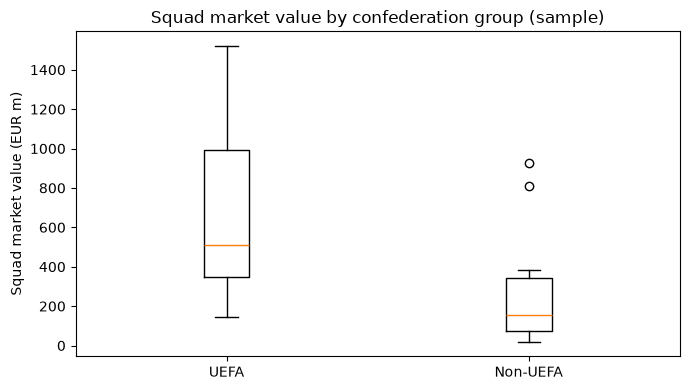

,UEFA,Non-UEFA
n,14.000000,14.000000
mean,669.554286,257.158571
median,510.600000,154.165000
std,456.038459,286.092335
min,146.400000,19.930000
max,1520.000000,928.200000
range,1373.600000,908.270000
skew,0.711366,1.589356
q1,346.200000,71.825000
q3,994.250000,340.750000


In [4]:
desc_table = pd.DataFrame(
    {
        "UEFA": describe(uefa_sample["squad_market_value_eur_m"]),
        "Non-UEFA": describe(non_uefa_sample["squad_market_value_eur_m"]),
    }
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [uefa_sample["squad_market_value_eur_m"], non_uefa_sample["squad_market_value_eur_m"]],
    tick_labels=["UEFA", "Non-UEFA"],
)
ax.set_ylabel("Squad market value (EUR m)")
ax.set_title("Squad market value by confederation group (sample)")
plt.tight_layout()
plt.savefig("../report/figs/task3_box.png", dpi=120)
plt.show()

desc_table

## Inferential statistics — confidence interval

We estimate a 95% confidence interval for the **population mean squad
market value of UEFA teams**, using the *t*-distribution.

In [5]:
ci = ci_mean(uefa_sample["squad_market_value_eur_m"], confidence=0.95)
print(f"n = {ci['n']}")
print(f"Sample mean squad value (UEFA) = EUR {ci['mean']:.1f}m")
print(f"95% CI: (EUR {ci['ci_low']:.1f}m, EUR {ci['ci_high']:.1f}m)")
ci

n = 14
Sample mean squad value (UEFA) = EUR 669.6m
95% CI: (EUR 406.2m, EUR 932.9m)


{'n': 14,
 'mean': np.float64(669.5542857142857),
 'se': np.float64(121.88140487634314),
 't_crit': np.float64(2.1603686564627913),
 'margin_of_error': np.float64(263.3087669005029),
 'ci_low': np.float64(406.2455188137828),
 'ci_high': np.float64(932.8630526147886),
 'confidence': 0.95}

## Inferential statistics — two-sample *t*-test

$H_0: \mu_{UEFA} = \mu_{non-UEFA}$ (mean squad market value equal between
UEFA and non-UEFA teams)

$H_1: \mu_{UEFA} > \mu_{non-UEFA}$ (one-sided: UEFA squads are worth more)

We first check the equal-variance assumption with Levene's test, then run
Welch's one-sided two-sample *t*-test, at $\alpha = 0.05$.

In [6]:
lev = levene_test(uefa_sample["squad_market_value_eur_m"], non_uefa_sample["squad_market_value_eur_m"])
print("Levene's test p-value:", lev["p_value"])

result = two_sample_ttest(
    uefa_sample["squad_market_value_eur_m"],
    non_uefa_sample["squad_market_value_eur_m"],
    equal_var=lev["p_value"] > 0.05,
    alternative="greater",
)
for k, v in result.items():
    print(f"{k}: {v}")

alpha = 0.05
if result["p_value"] < alpha:
    print(f"\nReject H0 (p={result['p_value']:.4f} < {alpha}): UEFA squads are significantly more valuable.")
else:
    print(f"\nFail to reject H0 (p={result['p_value']:.4f} >= {alpha}): no significant difference detected.")

Levene's test p-value: 0.12809547909560723
n1: 14
n2: 14
mean1: 669.5542857142857
mean2: 257.1585714285714
sd1: 456.0384588659548
sd2: 286.09233455321714
t_stat: 2.866249949978097
df: 26
p_value: 0.004061295828562372
alternative: greater
equal_var: True
cohens_d: 1.0833406518561952

Reject H0 (p=0.0041 < 0.05): UEFA squads are significantly more valuable.


## Conclusion

In our balanced sample (n=14 per group), **UEFA squads averaged EUR 669.6m**
in market value versus **EUR 257.2m for non-UEFA squads** — UEFA squads are
worth roughly **2.6× as much**, on average. Levene's test shows no strong
evidence of unequal variances (p=0.128), and the one-sided Welch's
two-sample *t*-test gives **t(26) = 2.87, p = 0.004** — we **reject H₀**:
UEFA squads are **significantly more valuable** than non-UEFA squads at
α=0.05 (Cohen's *d* = 1.08, a large effect).

The 95% confidence interval for the **population mean squad market value
of UEFA teams** is **(EUR 406.2m, EUR 932.9m)**.

**Takeaway:** Europe's financial dominance in club football translates
directly into national-team squad valuations — UEFA sides arrived at the
2026 World Cup carrying a decisively heavier price tag than the rest of
the world combined, consistent with UEFA teams' outsized recent World Cup
success (Spain's win continues a run of European champions).